In [981]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)

result_df = pd.read_csv('formula-1-world-championship-1950-2020/results.csv')
stats_df = pd.read_csv('formula-1-world-championship-1950-2020/status.csv')
drivers_df = pd.read_csv('formula-1-world-championship-1950-2020/drivers.csv')
races_df = pd.read_csv('formula-1-world-championship-1950-2020/races.csv')
constructor_df = pd.read_csv('formula-1-world-championship-1950-2020/constructors.csv')
constructor_stand_df = pd.read_csv('formula-1-world-championship-1950-2020/constructor_standings.csv')
driver_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/driver_standings.csv')
stops_df = pd.read_csv('formula-1-world-championship-1950-2020/pit_stops.csv')
pd.get_option("display.max_columns",None)

In [982]:
result_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [983]:
stats_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [984]:
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [985]:
races_df.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [986]:
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [987]:
driver_standings_df.head() 

,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


In [988]:
stops_df.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [989]:
races_df = races_df[['raceId', 'year', 'round', 'circuitId', 'date']]
races_df['raceId'] = races_df['raceId'].astype(int)


In [990]:
df = (
    result_df
    .merge(races_df, on='raceId')
    .merge(drivers_df, on='driverId')
    .merge(constructor_df, on='constructorId')
    .merge(stats_df, on='statusId')
)
df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,date,driverRef,number_y,code,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,1,1,2008-03-16,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,1,1,2008-03-16,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Finished
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,1,1,2008-03-16,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Finished
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,1,1,2008-03-16,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Finished
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,1,1,2008-03-16,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished


In [991]:
df = df.sort_values(['driverId', 'year', 'raceId'])
df['points_per_season'] = df.groupby(['driverId', 'year'])['points'].cumsum().shift().fillna(0)
df = df.reset_index(drop=True)
df.head(10)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,date,driverRef,number_y,code,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status,points_per_season
0,371,36,1,1,2,4,3,3,3,6.0,58,+18.595,5147365,20,3,1:26.351,221.083,1,2007,1,1,2007-03-18,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,0.0
1,392,37,1,1,2,4,2,2,2,8.0,56,+17.557,5552487,22,1,1:36.701,206.355,1,2007,2,2,2007-04-08,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,6.0
2,414,38,1,1,2,2,2,2,2,8.0,57,+2.360,5609875,18,2,1:34.270,206.674,1,2007,3,3,2007-04-15,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,14.0
3,436,39,1,1,2,4,2,2,2,8.0,65,+6.790,5503020,20,2,1:22.876,202.205,1,2007,4,4,2007-05-13,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,22.0
4,458,40,1,1,2,2,2,2,2,8.0,78,+4.095,6033424,28,2,1:15.372,159.528,1,2007,5,6,2007-05-27,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,30.0
5,479,41,1,1,2,1,1,1,1,10.0,70,1:44:11.292,6251292,37,2,1:16.494,205.239,1,2007,6,7,2007-06-10,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,38.0
6,501,42,1,1,2,1,1,1,1,10.0,73,1:31:09.965,5469965,20,2,1:13.222,206.101,1,2007,7,19,2007-06-17,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,48.0
7,525,43,1,1,2,2,3,3,3,6.0,70,+32.153,5486353,39,4,1:16.587,207.340,1,2007,8,8,2007-07-01,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,58.0
8,547,44,1,1,2,1,3,3,3,6.0,59,+39.373,4942447,11,4,1:21.675,226.600,1,2007,9,9,2007-07-08,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,64.0
9,575,45,1,1,2,10,9,9,9,0.0,59,\N,\N,29,3,1:33.401,198.421,11,2007,10,20,2007-07-22,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,70.0


In [992]:
df = df.sort_values(['driverId', 'raceId'])
df['overall_placement'] = df.groupby('driverId')['positionOrder'].shift().fillna(0)
df = df.reset_index(drop=True)
df.head(10)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,date,driverRef,number_y,code,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status,points_per_season,overall_placement
0,7573,1,1,1,1,18,\N,D,20,0.0,58,\N,\N,39,13,1:29.020,214.455,2,2009,1,1,2009-03-29,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Disqualified,98.0,0.0
1,7580,2,1,1,1,12,7,7,7,1.0,31,+1:00.733,4312825,17,11,1:39.141,201.276,1,2009,2,2,2009-04-05,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,0.0,20.0
2,7599,3,1,1,1,9,6,6,6,3.0,56,+1:11.866,7135351,39,12,1:54.665,171.138,1,2009,3,17,2009-04-19,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,1.0,7.0
3,7617,4,1,1,1,5,4,4,4,5.0,57,+22.096,5530278,13,6,1:34.915,205.269,1,2009,4,3,2009-04-26,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,4.0,6.0
4,7642,5,1,1,1,14,9,9,9,0.0,65,\N,\N,29,9,1:23.839,199.883,11,2009,5,4,2009-05-10,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,4.0
5,7665,6,1,1,1,19,12,12,12,0.0,77,\N,\N,65,8,1:15.706,158.824,11,2009,6,6,2009-05-24,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,9.0
6,7686,7,1,1,1,16,13,13,13,0.0,58,+1:20.454,5265302,53,15,1:28.562,216.986,1,2009,7,5,2009-06-07,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,9.0,12.0
7,7709,8,1,1,1,18,16,16,16,0.0,59,\N,\N,24,18,1:22.576,224.128,11,2009,8,9,2009-06-21,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,13.0
8,7731,9,1,1,1,5,18,18,18,0.0,59,\N,\N,46,15,1:35.367,194.331,11,2009,9,20,2009-07-12,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,16.0
9,7734,10,1,1,1,4,1,1,1,10.0,70,1:38:23.876,5903876,16,4,1:22.479,191.219,1,2009,10,11,2009-07-26,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,9.0,18.0


In [993]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   resultId           26759 non-null  int64  
 1   raceId             26759 non-null  int64  
 2   driverId           26759 non-null  int64  
 3   constructorId      26759 non-null  int64  
 4   number_x           26759 non-null  object 
 5   grid               26759 non-null  int64  
 6   position           26759 non-null  object 
 7   positionText       26759 non-null  object 
 8   positionOrder      26759 non-null  int64  
 9   points             26759 non-null  float64
 10  laps               26759 non-null  int64  
 11  time               26759 non-null  object 
 12  milliseconds       26759 non-null  object 
 13  fastestLap         26759 non-null  object 
 14  rank               26759 non-null  object 
 15  fastestLapTime     26759 non-null  object 
 16  fastestLapSpeed    267

In [994]:
df.isna().sum()

resultId             0
raceId               0
driverId             0
constructorId        0
number_x             0
grid                 0
position             0
positionText         0
positionOrder        0
points               0
laps                 0
time                 0
milliseconds         0
fastestLap           0
rank                 0
fastestLapTime       0
fastestLapSpeed      0
statusId             0
year                 0
round                0
circuitId            0
date                 0
driverRef            0
number_y             0
code                 0
forename             0
surname              0
dob                  0
nationality_x        0
url_x                0
constructorRef       0
name                 0
nationality_y        0
url_y                0
status               0
points_per_season    0
overall_placement    0
dtype: int64

In [995]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
resultId,26759.0,13380.977391,7726.134642,1.0,6690.5,13380.0,20069.5,26764.0
raceId,26759.0,551.687283,313.265036,1.0,300.0,531.0,811.0,1144.0
driverId,26759.0,278.673530,282.703039,1.0,57.0,172.0,399.5,862.0
constructorId,26759.0,50.180537,61.551498,1.0,6.0,25.0,63.0,215.0
grid,26759.0,11.134796,7.202860,0.0,5.0,11.0,17.0,34.0
positionOrder,26759.0,12.794051,7.665951,1.0,6.0,12.0,18.0,39.0
points,26759.0,1.987632,4.351209,0.0,0.0,0.0,2.0,50.0
laps,26759.0,46.301768,29.496557,0.0,23.0,53.0,66.0,200.0
statusId,26759.0,17.224971,26.026104,1.0,1.0,10.0,14.0,141.0
year,26759.0,1991.394372,19.952885,1950.0,1977.0,1991.0,2009.0,2024.0


In [996]:
columns_to_drop = [
    'url_y','url_x','position_x','fastestLapTime','positionText_x','time','driverRef',
    'constructorRef','nationality_y','positionText_y', 'number_y', 'nationality_x', 'points_x', 'statusId', 'code', 'number_x'
]


df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [997]:
df = df[df['raceId'] > 840]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5980 entries, 71 to 26758
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   resultId           5980 non-null   int64  
 1   raceId             5980 non-null   int64  
 2   driverId           5980 non-null   int64  
 3   constructorId      5980 non-null   int64  
 4   grid               5980 non-null   int64  
 5   position           5980 non-null   object 
 6   positionText       5980 non-null   object 
 7   positionOrder      5980 non-null   int64  
 8   points             5980 non-null   float64
 9   laps               5980 non-null   int64  
 10  milliseconds       5980 non-null   object 
 11  fastestLap         5980 non-null   object 
 12  rank               5980 non-null   object 
 13  fastestLapSpeed    5980 non-null   object 
 14  year               5980 non-null   int64  
 15  round              5980 non-null   int64  
 16  circuitId          5980 non

In [998]:
def podium_helper(pos):
    if pos == 1 or pos == 2 or pos == 3:
        return 1
    else:
        return 0

df['podium'] = df['positionOrder'].apply(podium_helper)
df.head()

,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,milliseconds,fastestLap,rank,fastestLapSpeed,year,round,circuitId,date,forename,surname,dob,name,status,points_per_season,overall_placement,podium
71,20780,841,1,1,2,2,2,2,18.0,58,5392556,41,8,211.382,2011,1,1,2011-03-27,Lewis,Hamilton,1985-01-07,McLaren,Finished,240.0,2.0,1
72,20808,842,1,1,2,8,8,8,4.0,56,5929789,54,5,196.575,2011,2,2,2011-04-10,Lewis,Hamilton,1985-01-07,McLaren,Finished,18.0,2.0,0
73,20825,843,1,1,3,1,1,1,25.0,56,5818226,48,2,195.424,2011,3,17,2011-04-17,Lewis,Hamilton,1985-01-07,McLaren,Finished,22.0,8.0,1
74,20852,844,1,1,4,4,4,4,12.0,58,5457790,48,4,213.264,2011,4,5,2011-05-08,Lewis,Hamilton,1985-01-07,McLaren,Finished,47.0,1.0,0
75,20874,845,1,1,3,2,2,2,18.0,66,5943931,52,1,193.227,2011,5,4,2011-05-22,Lewis,Hamilton,1985-01-07,McLaren,Finished,59.0,4.0,1


In [999]:
def status_helper(row):
    if row['status'] == 'Finished':
        return 'Finished'
    elif 'Lap' in row['status']:
        return 'Lapped'
    else:
        return 'DNF'

df['status_simp'] = df.apply(status_helper, axis= 1)
df = df.drop('status',  axis=1)
df.head()

,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,milliseconds,fastestLap,rank,fastestLapSpeed,year,round,circuitId,date,forename,surname,dob,name,points_per_season,overall_placement,podium,status_simp
71,20780,841,1,1,2,2,2,2,18.0,58,5392556,41,8,211.382,2011,1,1,2011-03-27,Lewis,Hamilton,1985-01-07,McLaren,240.0,2.0,1,Finished
72,20808,842,1,1,2,8,8,8,4.0,56,5929789,54,5,196.575,2011,2,2,2011-04-10,Lewis,Hamilton,1985-01-07,McLaren,18.0,2.0,0,Finished
73,20825,843,1,1,3,1,1,1,25.0,56,5818226,48,2,195.424,2011,3,17,2011-04-17,Lewis,Hamilton,1985-01-07,McLaren,22.0,8.0,1,Finished
74,20852,844,1,1,4,4,4,4,12.0,58,5457790,48,4,213.264,2011,4,5,2011-05-08,Lewis,Hamilton,1985-01-07,McLaren,47.0,1.0,0,Finished
75,20874,845,1,1,3,2,2,2,18.0,66,5943931,52,1,193.227,2011,5,4,2011-05-22,Lewis,Hamilton,1985-01-07,McLaren,59.0,4.0,1,Finished


In [1000]:
df[["grid", "podium"]].groupby(['grid'], as_index=False).mean().sort_values(by='podium', ascending=False)

,grid,podium
1,1,0.807692
2,2,0.686620
3,3,0.503497
4,4,0.342657
5,5,0.192308
6,6,0.139860
7,7,0.080702
10,10,0.045775
9,9,0.041958
8,8,0.031579


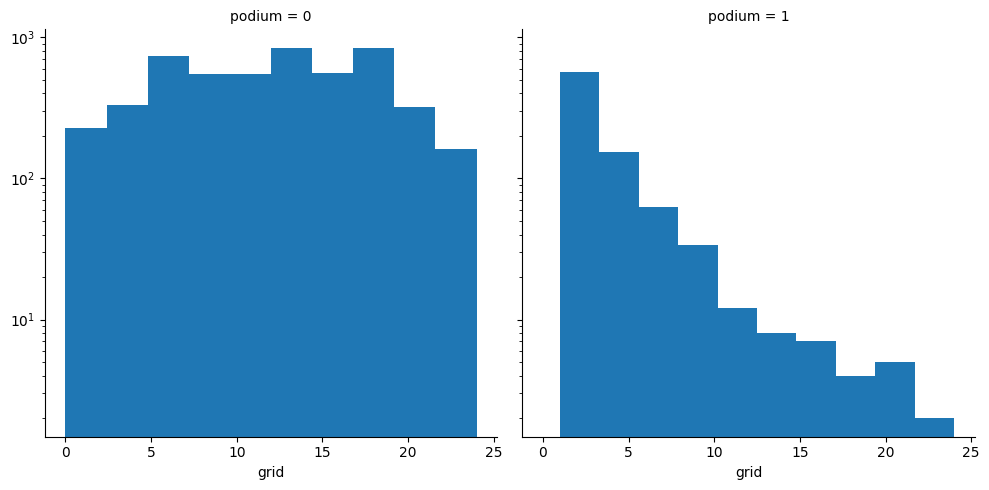

In [1001]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'grid', bins=10, log=True)

In [1002]:
df[["points_per_season", "podium"]].groupby(['points_per_season'], as_index=False).mean().sort_values(by='podium', ascending=False)

,points_per_season,podium
376,530.0,1.0
304,297.0,1.0
293,279.5,1.0
294,280.0,1.0
295,281.0,1.0
...,...,...
345,356.0,0.0
270,258.0,0.0
269,257.0,0.0
21,21.0,0.0


Vizualizing the pointers before the race and how it relates to making the podium

Trying to get rid of some of the noise being getting rid of the drivers who don't have enough data

In [1003]:
min_races = 10
drivers_keep = driver_counts[driver_counts['num_races'] >= min_races]['driverId']
df= df[df['driverId'].isin(drivers_keep)]
df[["driverId", "podium"]].groupby(['driverId'], as_index=False).mean().sort_values(by='podium', ascending=False)

,driverId,podium
0,1,0.582456
42,830,0.535885
2,3,0.444444
13,20,0.432773
11,17,0.379310
...,...,...
33,820,0.000000
36,823,0.000000
37,824,0.000000
40,828,0.000000


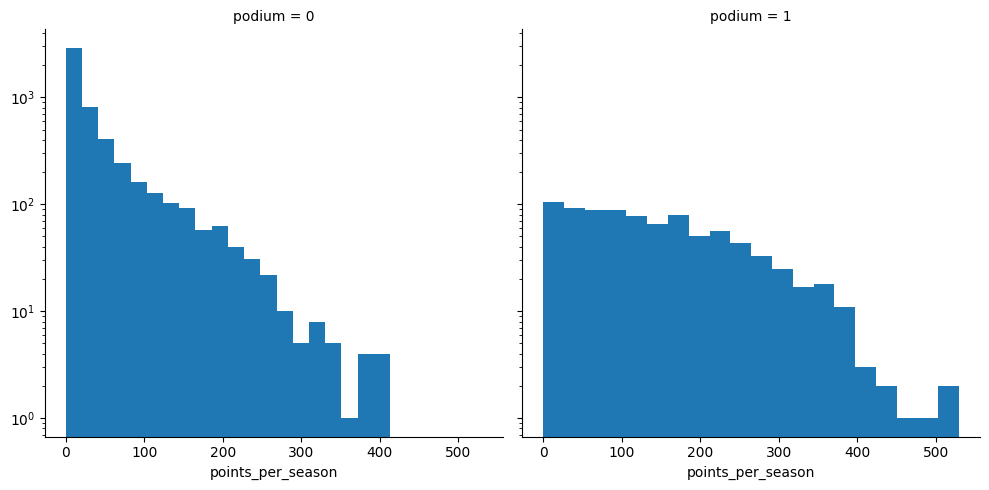

In [1004]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'points_per_season', bins=20, log=True)

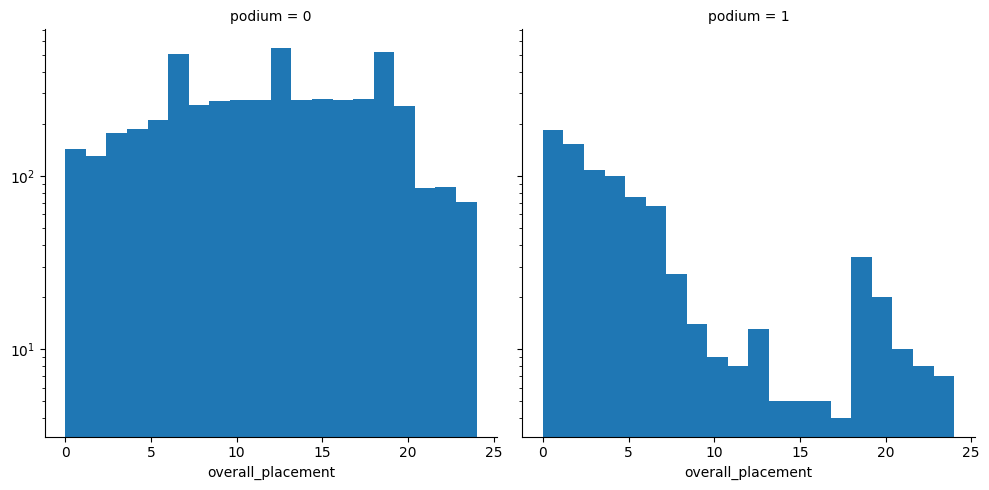

In [1005]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'overall_placement', bins=20, log=True)